# 📈 Regresión Lineal — Datos Financieros Alpha Vantage
**Minería de Datos — Guía 2 | CORHUILA 2026**

Objetivo: predecir el precio de **cierre (`close`)** usando indicadores técnicos como RSI, MACD, SMA y Bandas de Bollinger.

Pipeline:
1. Conexión a PostgreSQL (`alphavantage_etl`)
2. EDA — Análisis Exploratorio
3. Regresión Lineal **Simple** (`close ~ sma_20`)
4. Regresión Lineal **Múltiple** (`close ~ rsi + macd + sma_20 + sma_50 + bb_upper + bb_lower`)
5. Diagnósticos y comparación de modelos

---
## 🔧 Fase 1 — Importaciones

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas      {pd.__version__}')
print(f'   numpy       {np.__version__}')
print(f'   seaborn     {sns.__version__}')
print(f'   statsmodels {sm.__version__}')

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       2.4.3
   seaborn     0.13.2
   statsmodels 0.14.4


---
## 🗄️ Fase 2 — Conexión a PostgreSQL

In [61]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

import pandas as pd

SYMBOL = 'AAPL'

QUERY = """
SELECT
    a.symbol,
    p.fecha,
    p.open,
    p.high,
    p.low,
    p.close,
    p.volume,
    p.daily_return,
    p.price_range,
    i.rsi,
    i.macd,
    i.macd_signal,
    i.sma_20,
    i.sma_50,
    i.bb_upper,
    i.bb_lower,
    i.bb_middle
FROM precios_diarios p
JOIN acciones a 
    ON p.accion_id = a.id
JOIN indicadores_tecnicos i 
    ON i.accion_id = a.id 
    AND i.fecha = p.fecha
WHERE a.symbol = %s
ORDER BY p.fecha;
"""

try:
    df = pd.read_sql(QUERY, engine, params=(SYMBOL,))  # ← AQUÍ ESTÁ EL FIX
    
    if df.empty:
        print("⚠️ No se encontraron datos para el símbolo:", SYMBOL)
    else:
        df["fecha"] = pd.to_datetime(df["fecha"])
        
        print(f'✅ Datos cargados exitosamente')
        print(f'   Símbolo      : {SYMBOL}')
        print(f'   Filas        : {df.shape[0]:,}')
        print(f'   Columnas     : {df.shape[1]}')
        print(f'   Rango fechas : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
        
        display(df.head())

except Exception as e:
    print("❌ Error al cargar los datos:")
    print(e)

✅ Datos cargados exitosamente
   Símbolo      : AAPL
   Filas        : 99
   Columnas     : 17
   Rango fechas : 2025-11-21 → 2026-04-16


,symbol,fecha,open,high,low,close,volume,daily_return,price_range,rsi,macd,macd_signal,sma_20,sma_50,bb_upper,bb_lower,bb_middle
0,AAPL,2025-11-21,265.95,273.33,265.6700,271.49,59030832,NaN,7.6600,None,None,None,None,None,274.0655,265.3098,269.6877
1,AAPL,2025-11-24,270.90,277.00,270.9000,275.92,65585796,0.016317,6.1000,None,None,None,None,None,275.0924,265.0191,270.0558
2,AAPL,2025-11-25,275.27,280.38,275.2500,276.97,46914220,0.003805,5.1300,None,None,None,None,None,276.2158,264.7180,270.4669
3,AAPL,2025-11-26,276.96,279.53,276.6300,277.55,33431423,0.002094,2.9000,None,None,None,None,None,277.3038,264.4401,270.8720
4,AAPL,2025-11-28,277.26,279.00,275.9865,278.85,20135620,0.004684,3.0135,None,None,None,None,None,278.5151,263.9993,271.2572


In [62]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print('=' * 50)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('=' * 50)
print(df.info())
print('\n📊 Valores nulos por columna:')
print(df.isnull().sum())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   symbol        99 non-null     object        
 1   fecha         99 non-null     datetime64[ns]
 2   open          99 non-null     float64       
 3   high          99 non-null     float64       
 4   low           99 non-null     float64       
 5   close         99 non-null     float64       
 6   volume        99 non-null     int64         
 7   daily_return  98 non-null     float64       
 8   price_range   99 non-null     float64       
 9   rsi           0 non-null      object        
 10  macd          0 non-null      object        
 11  macd_signal   0 non-null      object        
 12  sma_20        0 non-null      object        
 13  sma_50        0 non-null      object        
 14  bb_upper      99 non-null     float64       
 15  bb_lower

---
## 📊 Fase 3 — EDA: Análisis Exploratorio de Datos

In [12]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['close', 'rsi', 'macd', 'sma_20', 'sma_50', 'bb_upper', 'bb_lower', 'volume']

desc = df[vars_num].describe().round(4)
print('📊 ESTADÍSTICAS DESCRIPTIVAS')
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
          close  bb_upper  bb_lower        volume
count   99.0000   99.0000   99.0000  9.900000e+01
mean   264.5099  277.4169  253.5274  4.558066e+07
std     10.1512    7.5207    9.5029  1.791592e+07
min    246.6300  260.4282  240.7259  1.791057e+07
25%    256.9500  274.1578  244.9842  3.462049e+07
50%    262.5200  279.9841  253.2177  4.168898e+07
75%    273.6750  282.8955  263.3785  5.041421e+07
max    286.1900  287.0909  269.4971  1.446320e+08


In [19]:
# Asegurar orden temporal
df = df.sort_values('fecha').reset_index(drop=True)

# =====================
# RSI (14)
# =====================
delta = df['close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# =====================
# MACD
# =====================
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()

df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

print("✅ Indicadores calculados correctamente")

✅ Indicadores calculados correctamente


In [24]:
df[['rsi','macd','macd_signal']].describe()


,rsi,macd,macd_signal
count,85.000000,99.000000,99.000000
mean,42.040906,-1.024150,-1.014768
std,18.041904,2.494008,2.090993
min,6.467181,-6.472196,-5.249167
25%,27.963998,-3.377774,-2.886346
50%,41.618693,-0.639019,-0.492161
75%,54.036087,0.924971,0.704469
max,83.703525,3.135314,2.118736


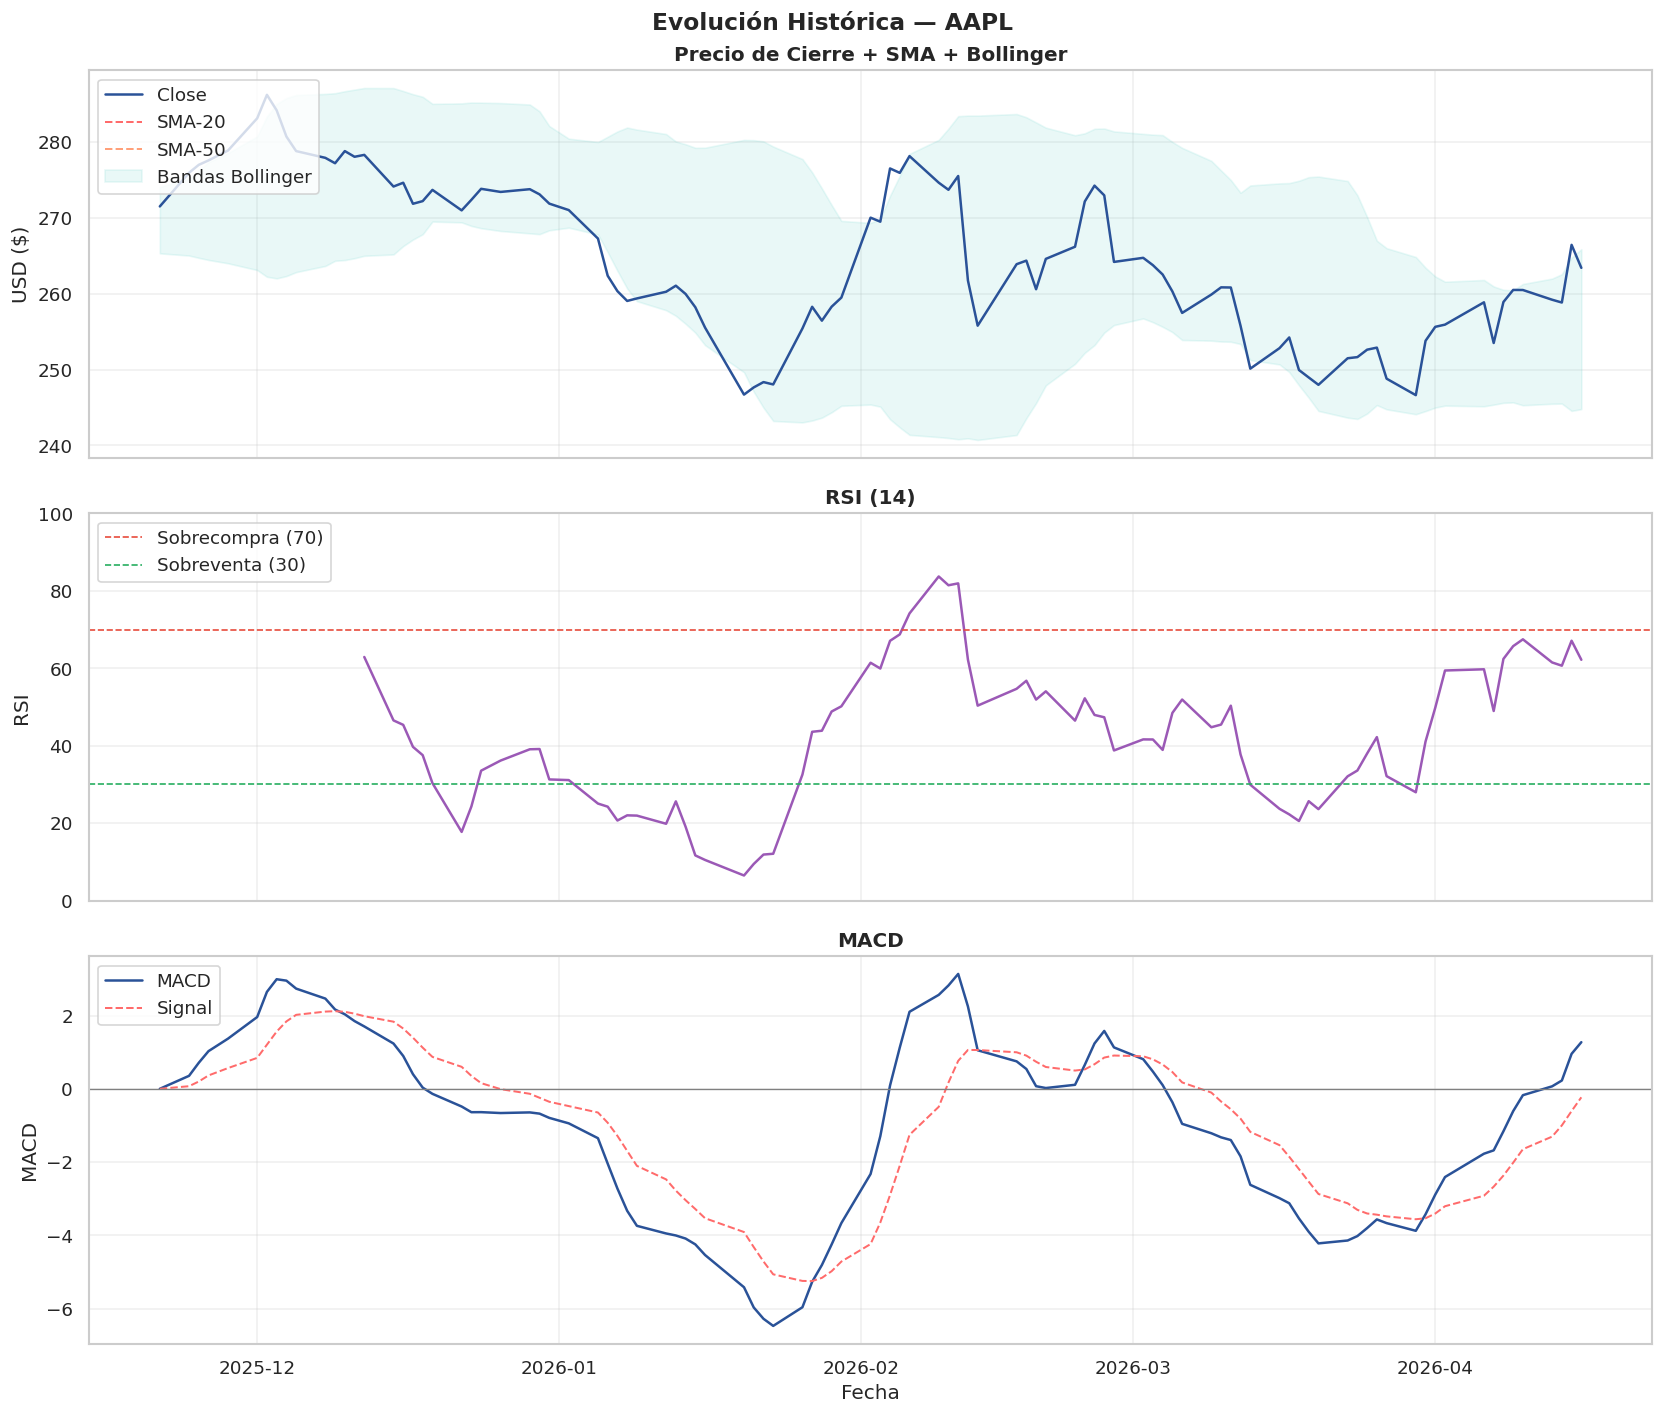

In [33]:
# ── CELDA 5: Evolución del precio de cierre ──────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Evolución Histórica — {SYMBOL}', fontsize=14, fontweight='bold')

# Precio de cierre con SMA
axes[0].plot(df['fecha'], df['close'],  color='#2a5298', linewidth=1.5, label='Close')
axes[0].plot(df['fecha'], df['sma_20'], color='#ff6b6b', linewidth=1.2, linestyle='--', label='SMA-20')
axes[0].plot(df['fecha'], df['sma_50'], color='#ffa07a', linewidth=1.2, linestyle='--', label='SMA-50')
axes[0].fill_between(df['fecha'], df['bb_lower'], df['bb_upper'],
                     alpha=0.12, color='#4ecdc4', label='Bandas Bollinger')
axes[0].set_title('Precio de Cierre + SMA + Bollinger', fontweight='bold')
axes[0].set_ylabel('USD ($)')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# RSI
axes[1].plot(df['fecha'], df['rsi'], color='#9b59b6', linewidth=1.5)
axes[1].axhline(70, color='#e74c3c', linestyle='--', linewidth=1, label='Sobrecompra (70)')
axes[1].axhline(30, color='#27ae60', linestyle='--', linewidth=1, label='Sobreventa (30)')
axes[1].set_title('RSI (14)', fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# MACD
axes[2].plot(df['fecha'], df['macd'],        color='#2a5298', linewidth=1.5, label='MACD')
axes[2].plot(df['fecha'], df['macd_signal'], color='#ff6b6b', linewidth=1.2,
             linestyle='--', label='Signal')
axes[2].axhline(0, color='gray', linestyle='-', linewidth=0.8)
axes[2].set_title('MACD', fontweight='bold')
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Fecha')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../data/graficas', exist_ok=True)
plt.savefig('../data/graficas/eda_series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

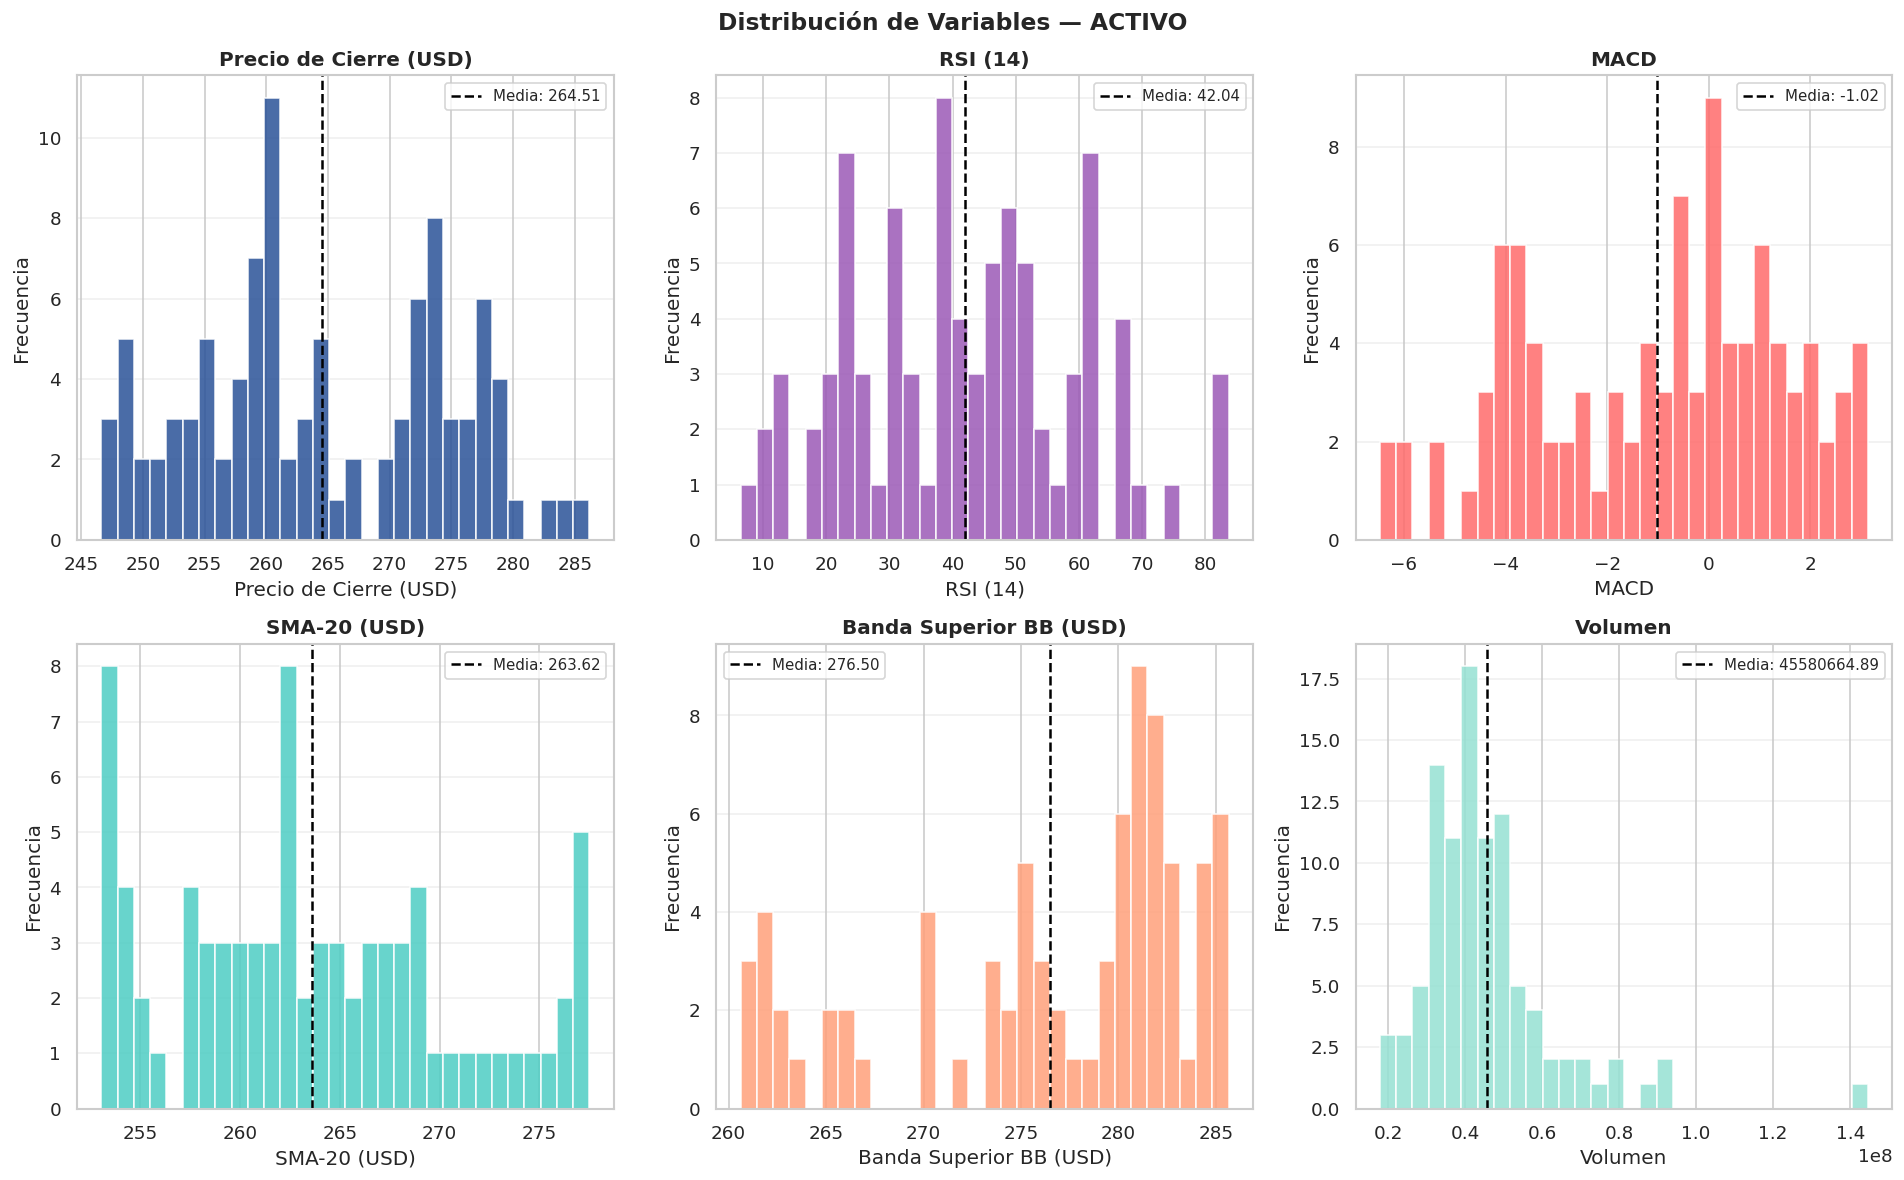

In [41]:
# ─────────────────────────────────────────────
# 1️⃣ SMA 20
# ─────────────────────────────────────────────
df['sma_20'] = df['close'].rolling(window=20, min_periods=20).mean()

# ─────────────────────────────────────────────
# 2️⃣ RSI (14)
# ─────────────────────────────────────────────
delta = df['close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# ─────────────────────────────────────────────
# 3️⃣ MACD
# ─────────────────────────────────────────────
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()

df['macd'] = ema_12 - ema_26

# ─────────────────────────────────────────────
# 4️⃣ Bandas de Bollinger
# ─────────────────────────────────────────────
rolling_mean = df['close'].rolling(window=20).mean()
rolling_std = df['close'].rolling(window=20).std()

df['bb_upper'] = rolling_mean + (2 * rolling_std)
df['bb_lower'] = rolling_mean - (2 * rolling_std)

# ─────────────────────────────────────────────
# 5️⃣ HISTOGRAMAS
# ─────────────────────────────────────────────

SYMBOL = "ACTIVO"

vars_hist = {
    'close':    ('Precio de Cierre (USD)',  '#2a5298'),
    'rsi':      ('RSI (14)',                '#9b59b6'),
    'macd':     ('MACD',                    '#ff6b6b'),
    'sma_20':   ('SMA-20 (USD)',            '#4ecdc4'),
    'bb_upper': ('Banda Superior BB (USD)', '#ffa07a'),
    'volume':   ('Volumen',                 '#95e1d3'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Distribución de Variables — {SYMBOL}', fontsize=14, fontweight='bold')

for ax, (col, (label, color)) in zip(axes.flat, vars_hist.items()):
    
    if col in df.columns:
        data = df[col].dropna()
        
        if len(data) > 0:
            ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
            media = data.mean()
            ax.axvline(media, color='black', linestyle='--',
                       linewidth=1.5, label=f'Media: {media:.2f}')
            ax.set_title(label, fontweight='bold')
            ax.set_xlabel(label)
            ax.set_ylabel('Frecuencia')
            ax.legend(fontsize=9)
            ax.grid(axis='y', alpha=0.3)
        else:
            ax.set_title(f'{label}\n(Sin datos)', fontweight='bold')
    else:
        ax.set_title(f'{col} no existe', color='red')

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

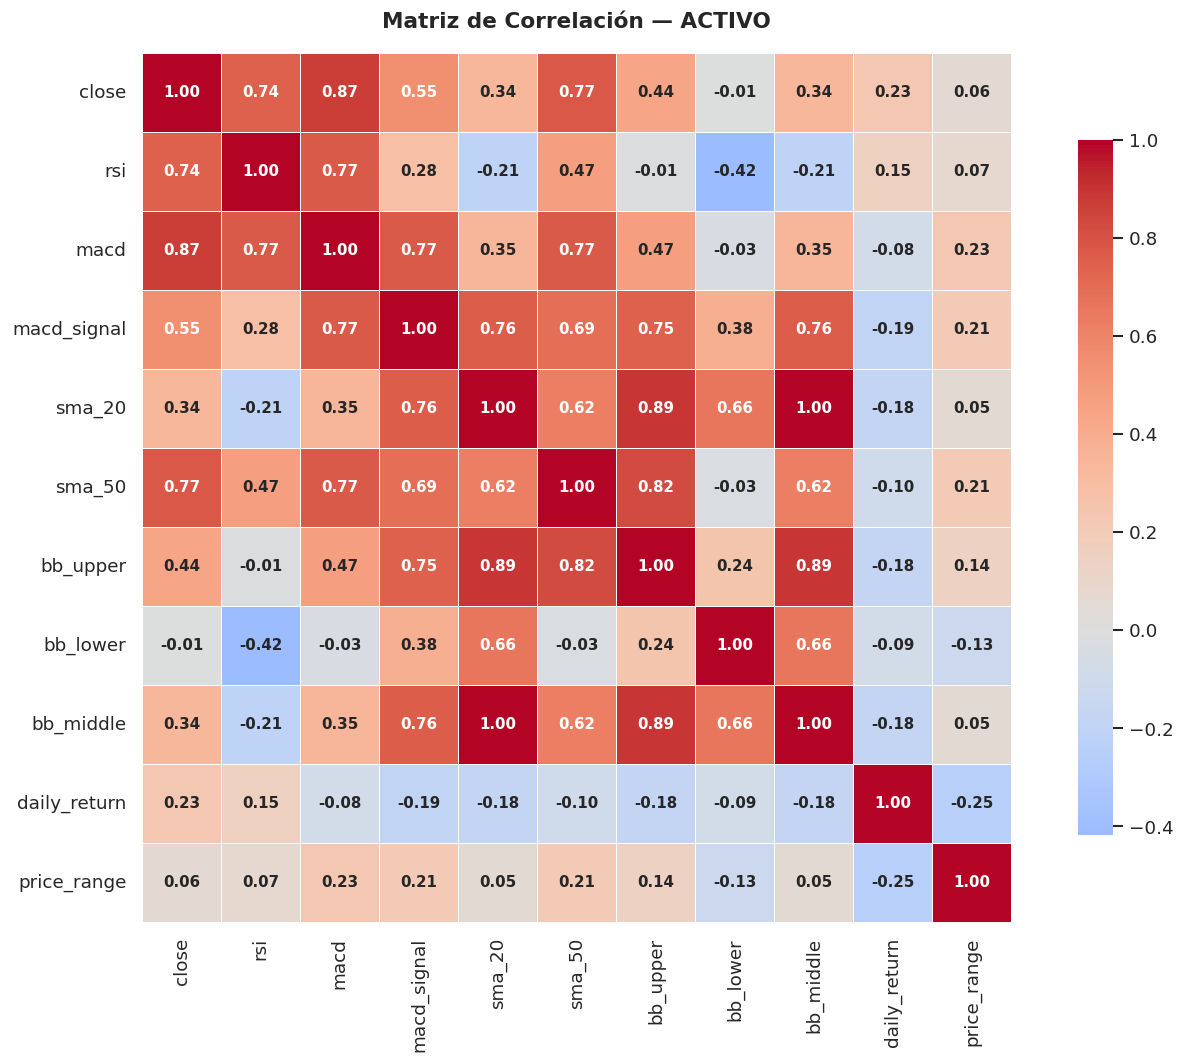


📊 Correlación con close (ordenada):
macd            0.8707
sma_50          0.7731
rsi             0.7416
macd_signal     0.5512
bb_upper        0.4383
sma_20          0.3370
bb_middle       0.3370
daily_return    0.2285
price_range     0.0635
bb_lower       -0.0066
Name: close, dtype: float64


In [40]:
# ─────────────────────────────────────────────
# INDICADORES TÉCNICOS
# ─────────────────────────────────────────────

# 1️⃣ SMA 20
df['sma_20'] = df['close'].rolling(window=20, min_periods=20).mean()

# 2️⃣ SMA 50
df['sma_50'] = df['close'].rolling(window=50, min_periods=50).mean()

# 3️⃣ RSI (14)
delta = df['close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# 4️⃣ MACD
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()

df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 5️⃣ Bandas de Bollinger
df['bb_middle'] = df['close'].rolling(window=20).mean()
rolling_std = df['close'].rolling(window=20).std()

df['bb_upper'] = df['bb_middle'] + (2 * rolling_std)
df['bb_lower'] = df['bb_middle'] - (2 * rolling_std)

# 6️⃣ Daily Return
df['daily_return'] = df['close'].pct_change()

# 7️⃣ Price Range
df['price_range'] = df['high'] - df['low']

# ─────────────────────────────────────────────
# MATRIZ DE CORRELACIÓN
# ─────────────────────────────────────────────

SYMBOL = "ACTIVO"

vars_corr = [
    'close', 'rsi', 'macd', 'macd_signal',
    'sma_20', 'sma_50',
    'bb_upper', 'bb_lower', 'bb_middle',
    'daily_return', 'price_range'
]

# Filtrar solo columnas existentes
vars_corr = [col for col in vars_corr if col in df.columns]

# Eliminar filas con NaN
corr = df[vars_corr].dropna().corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9, 'weight': 'bold'}
)

plt.title(f'Matriz de Correlación — {SYMBOL}',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png',
            dpi=150, bbox_inches='tight')

plt.show()

print('\n📊 Correlación con close (ordenada):')
print(
    corr['close']
    .drop('close')
    .sort_values(ascending=False)
    .round(4)
)

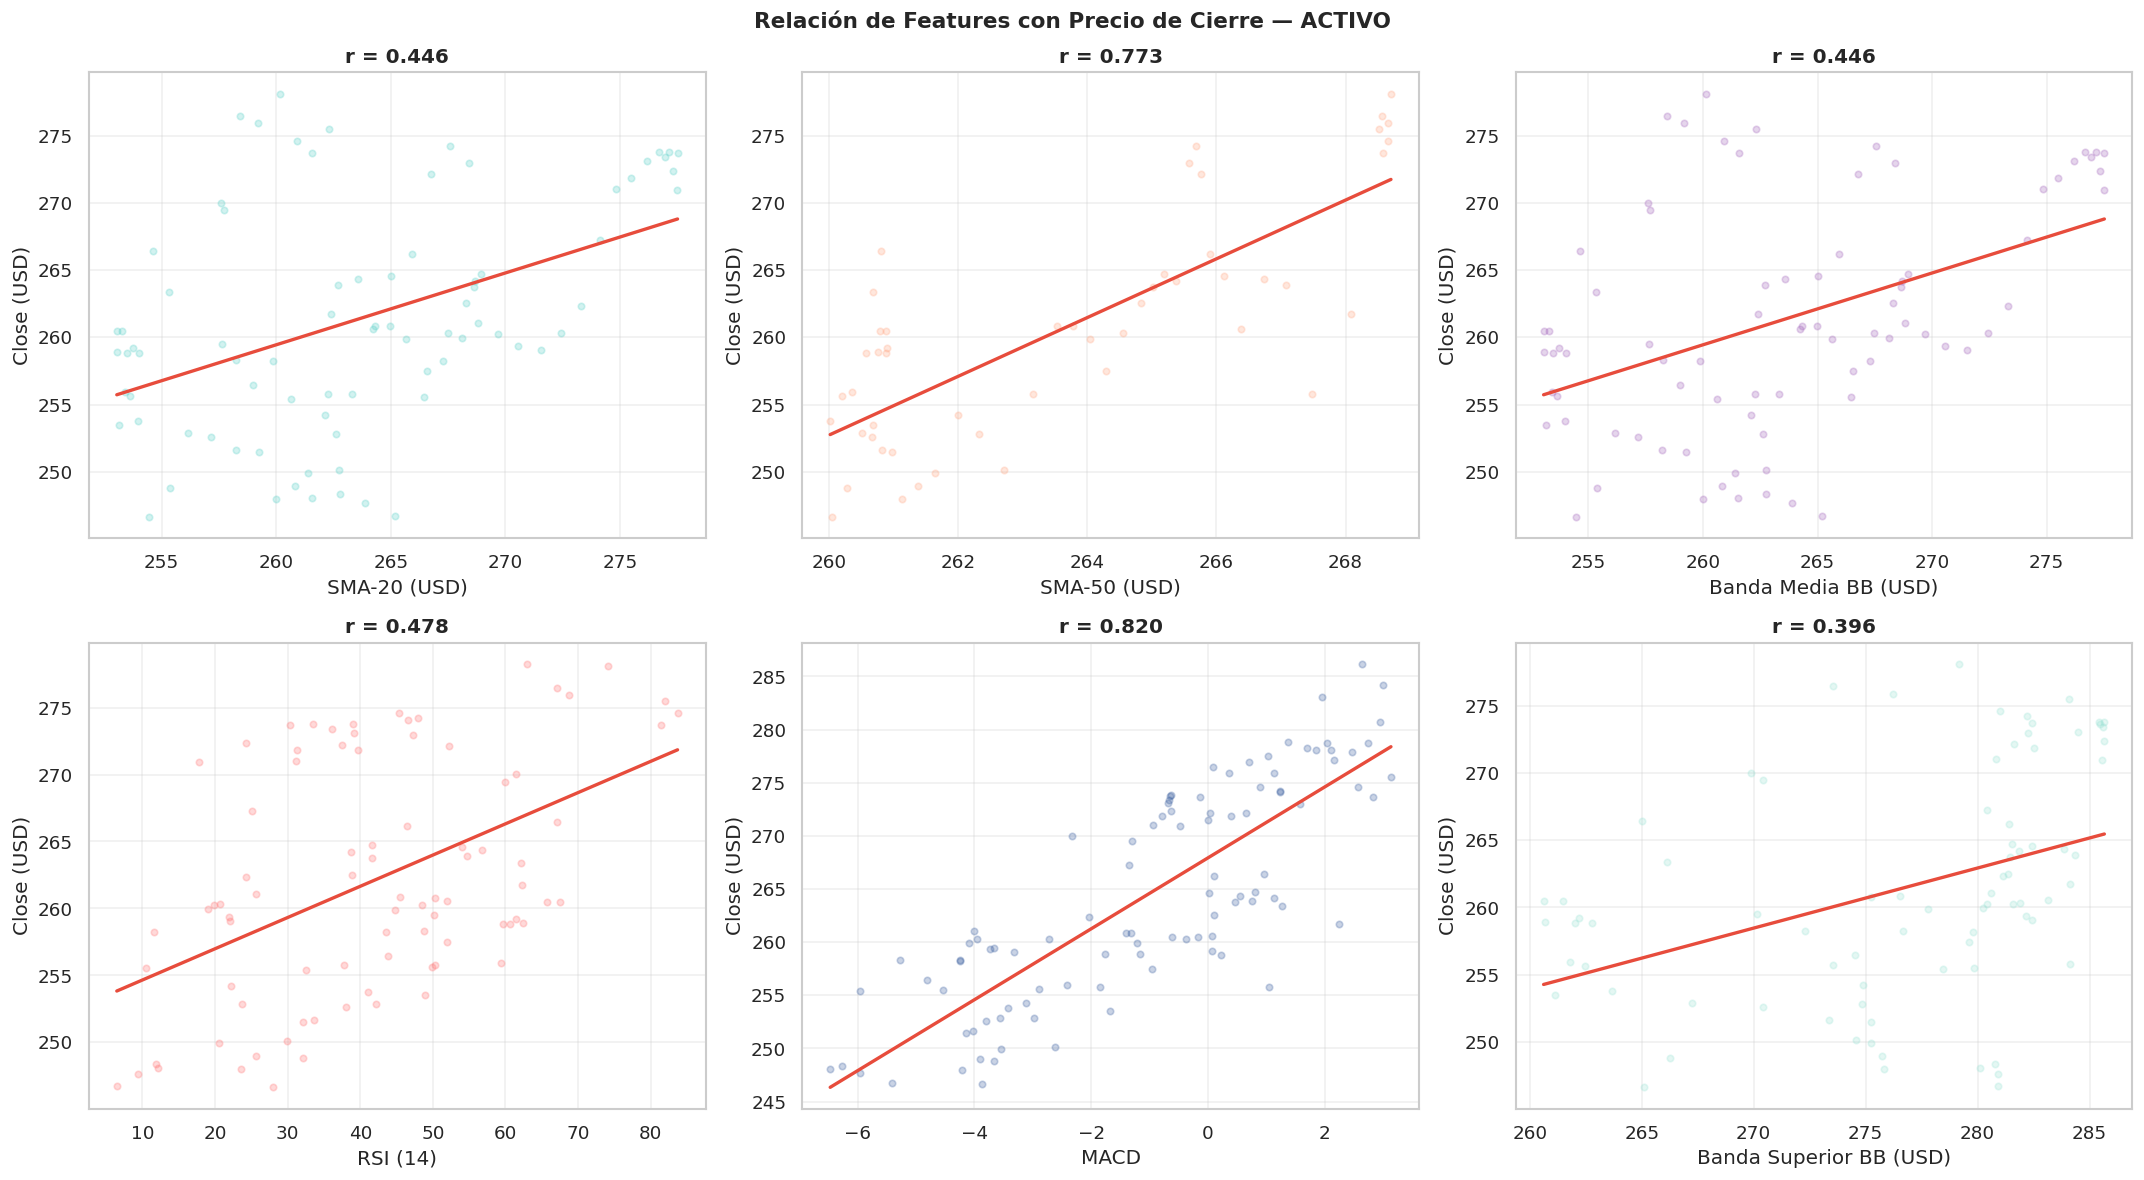

In [42]:
# ── CELDA 8: Scatter plots — features vs close ───────────────
pares = [
    ('sma_20',     'SMA-20 (USD)',            '#4ecdc4'),
    ('sma_50',     'SMA-50 (USD)',            '#ffa07a'),
    ('bb_middle',  'Banda Media BB (USD)',    '#9b59b6'),
    ('rsi',        'RSI (14)',                '#ff6b6b'),
    ('macd',       'MACD',                   '#2a5298'),
    ('bb_upper',   'Banda Superior BB (USD)', '#95e1d3'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Relación de Features con Precio de Cierre — {SYMBOL}',
             fontsize=13, fontweight='bold')

for ax, (feature, xlabel, color) in zip(axes.flat, pares):
    data_clean = df[['close', feature]].dropna()
    ax.scatter(data_clean[feature], data_clean['close'],
               alpha=0.25, s=15, color=color)
    z = np.polyfit(data_clean[feature], data_clean['close'], 1)
    p = np.poly1d(z)
    xp = np.linspace(data_clean[feature].min(), data_clean[feature].max(), 200)
    ax.plot(xp, p(xp), color='#e74c3c', linewidth=2)
    r = data_clean[['close', feature]].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Close (USD)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📐 Fase 4 — Regresión Lineal Simple

**Variable objetivo:** `close`  
**Predictor:** `sma_20` (la media móvil de 20 días suele tener la correlación más alta con el precio de cierre)

**Modelo:** `ŷ = β₀ + β₁ · sma_20 + ε`

In [43]:
# ── CELDA 9: Preparar datos y split train/test ────────────────
df_model = df[['close', 'sma_20', 'sma_50', 'rsi', 'macd',
               'bb_upper', 'bb_lower', 'bb_middle']].dropna().copy()

X_simple = df_model[['sma_20']].values
y        = df_model['close'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f'Dataset limpio: {df_model.shape[0]} filas')
print(f'Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)')

Dataset limpio: 50 filas
Train: 40 muestras (80%)
Test : 10 muestras  (20%)


In [44]:
# ── CELDA 10: Entrenamiento — modelo simple (scikit-learn) ────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f'Intercepto  β₀ : {modelo_simple.intercept_:.4f}')
print(f'Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}')
print(f'\nEcuación : close = {modelo_simple.intercept_:.3f}'
      f' + {modelo_simple.coef_[0]:.3f} × sma_20')

Intercepto  β₀ : 99.3043
Coeficiente β₁ : 0.6212

Ecuación : close = 99.304 + 0.621 × sma_20


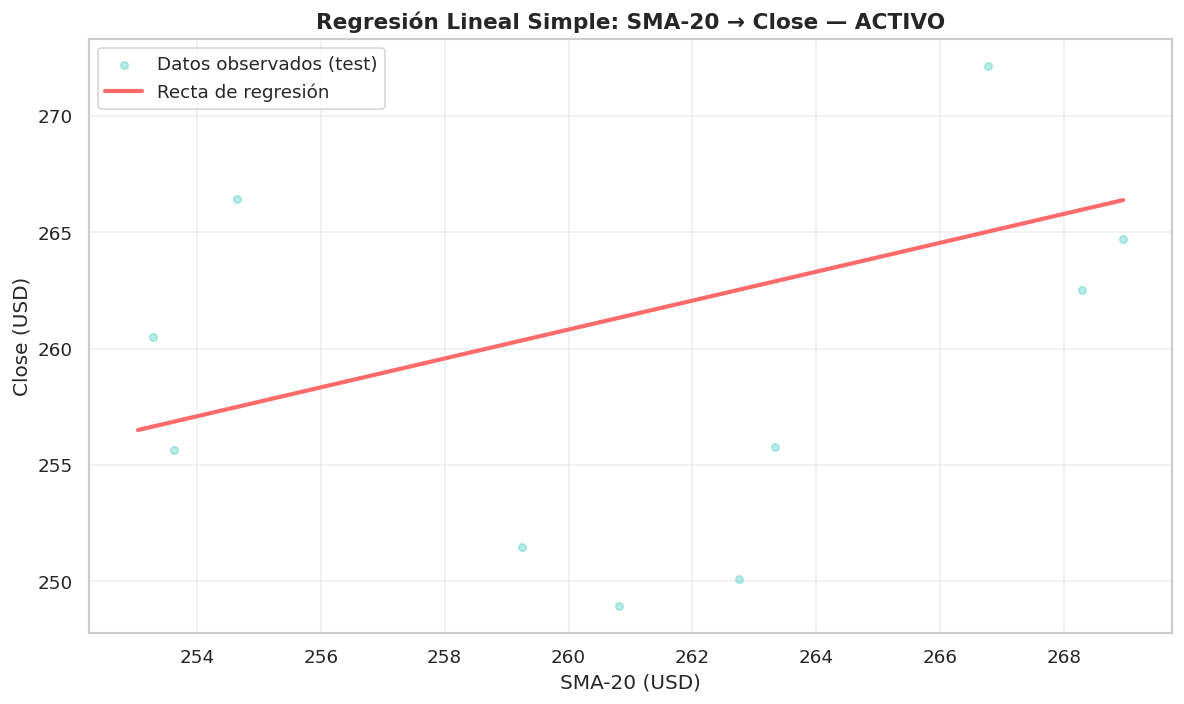

In [45]:
# ── CELDA 11: Visualizar la recta de regresión ────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.40, s=20,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('SMA-20 (USD)', fontsize=12)
ax.set_ylabel('Close (USD)', fontsize=12)
ax.set_title(f'Regresión Lineal Simple: SMA-20 → Close — {SYMBOL}',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print('=' * 50)
print('    MÉTRICAS — REGRESIÓN LINEAL SIMPLE')
print('=' * 50)
print(f'  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)')
print(f'  MSE  (error cuadrático med)  : {mse:.4f}')
print(f'  RMSE (raíz del MSE)          : {rmse:.4f} USD')
print(f'  MAE  (error absoluto medio)  : {mae:.4f} USD')
print('=' * 50)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : -0.1216  (-12.16%)
  MSE  (error cuadrático med)  : 59.7561
  RMSE (raíz del MSE)          : 7.7302 USD
  MAE  (error absoluto medio)  : 6.6991 USD


In [ ]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df_model['sma_20'])
modelo_ols_simple = sm.OLS(df_model['close'], X_ols).fit()

print(modelo_ols_simple.summary())

### 🔬 Supuesto 1: Normalidad de Residuos
Los residuos `ε = y − ŷ` deben distribuirse normalmente para que los p-values sean válidos.

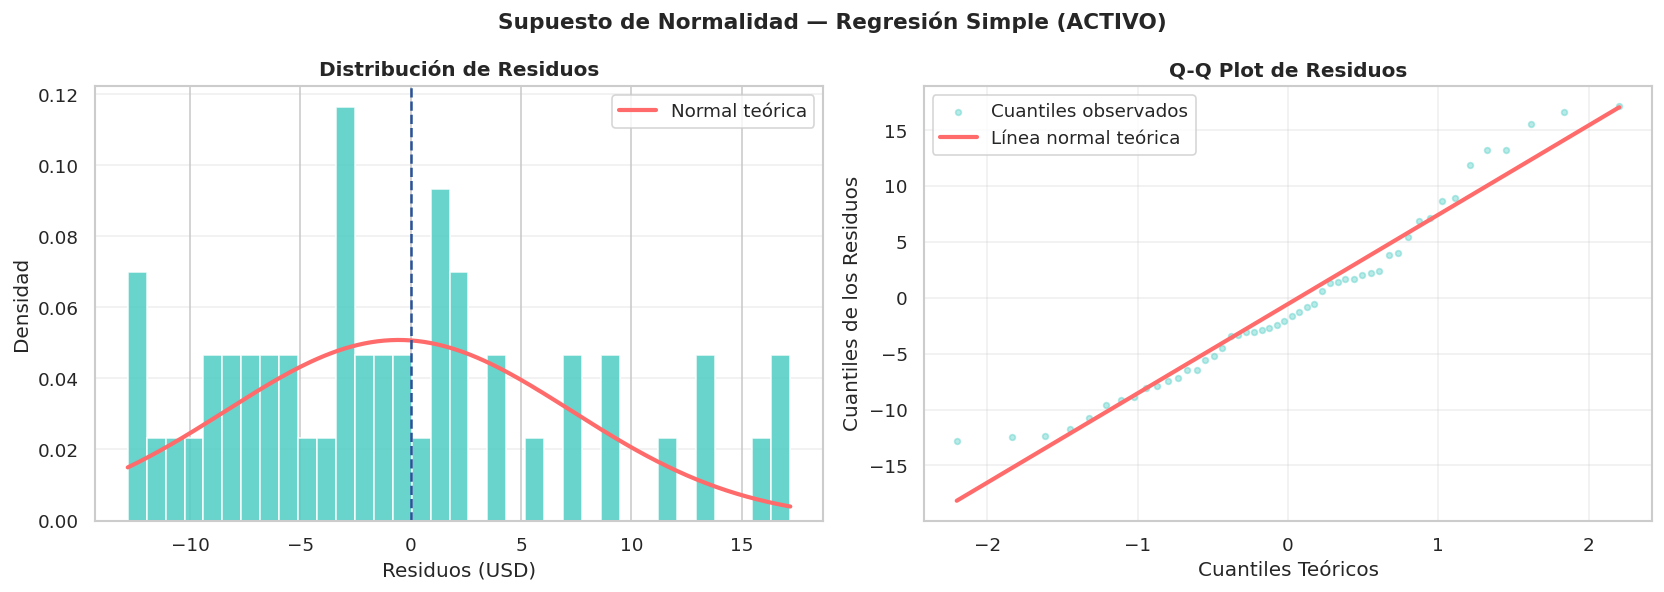


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9558
   p-value       : 0.059447
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [47]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df_model[['sma_20']].values)
residuos   = df_model['close'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Supuesto de Normalidad — Regresión Simple ({SYMBOL})',
             fontsize=13, fontweight='bold')

# Histograma con curva normal
axes[0].hist(residuos, bins=35, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (USD)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.40, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f'\n🔬 Test de Shapiro-Wilk:')
print(f'   Estadístico W : {stat_sw:.4f}')
print(f'   p-value       : {p_sw:.6f}')
if p_sw > 0.05:
    print('   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)')
else:
    print('   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)')
    print('   Nota: Con n grande el test es muy sensible — revisar Q-Q plot')

### 🔬 Supuesto 2: Homocedasticidad
La varianza de los residuos debe ser constante. Si se expande en forma de cono → **heterocedasticidad**.

                            OLS Regression Results                            
Dep. Variable:                  close   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     19.38
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           3.37e-05
Time:                        00:25:49   Log-Likelihood:                -275.37
No. Observations:                  80   AIC:                             554.7
Df Residuals:                      78   BIC:                             559.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.5544     32.001      3.767      0.0

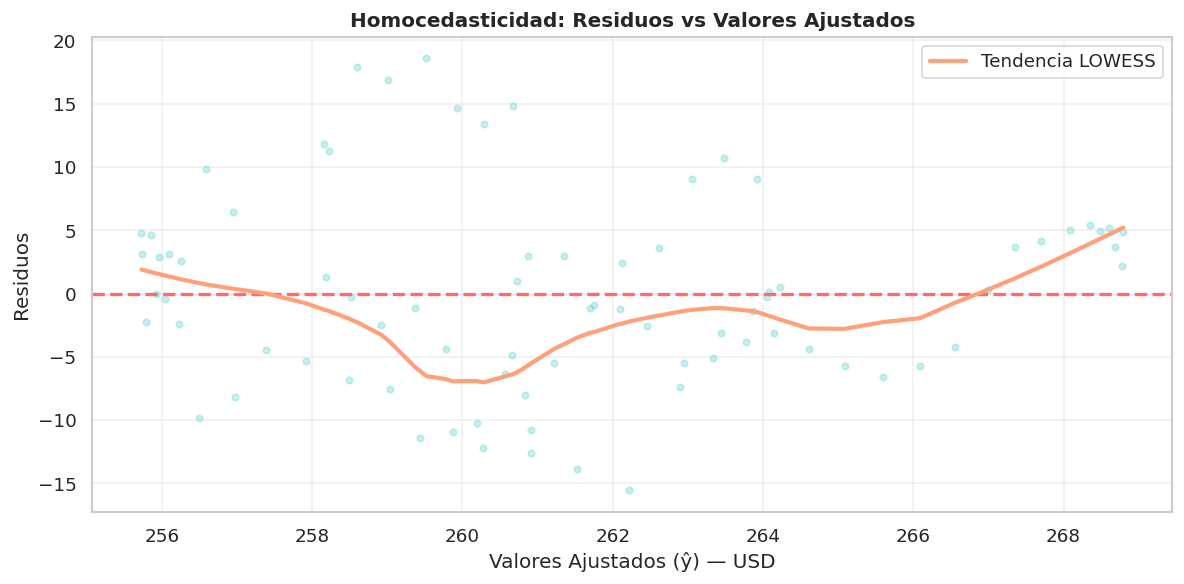


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 2.4406
   p-value        : 0.118230
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [49]:
# ─────────────────────────────────────────────
# CELDA 15: Homocedasticidad (modelo simple)
# ─────────────────────────────────────────────

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Variables del modelo
# Ejemplo: predecir close usando sma_20 (puedes cambiarla)
df_model = df[['close', 'sma_20']].dropna()

X = df_model[['sma_20']]
y = df_model['close']

# Agregar constante
X = sm.add_constant(X)

# 🔹 Crear y ajustar modelo OLS
modelo_ols_simple = sm.OLS(y, X).fit()

print(modelo_ols_simple.summary())

# ─────────────────────────────────────────────
# RESIDUOS Y VALORES AJUSTADOS
# ─────────────────────────────────────────────

residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

# ─────────────────────────────────────────────
# GRÁFICA
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 5))

plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4')

plt.axhline(0, color='#ff6b6b',
            linestyle='--', linewidth=2)

# LOWESS
lowess = sm.nonparametric.lowess(residuos_ols,
                                 ajustados_ols,
                                 frac=0.3)

plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a',
         linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores Ajustados (ŷ) — USD', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# TEST BREUSCH-PAGAN
# ─────────────────────────────────────────────

lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print('\n🔬 Test de Breusch-Pagan (Homocedasticidad):')
print(f'   Estadístico LM : {lm:.4f}')
print(f'   p-value        : {lm_p:.6f}')

if lm_p > 0.05:
    print('   Conclusión     : ✅ Homocedasticidad (p > 0.05)')
else:
    print('   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)')

---
## 📐 Fase 5 — Regresión Lineal Múltiple

**Variables independientes:** `sma_20`, `sma_50`, `rsi`, `macd`, `bb_upper`, `bb_lower`

**Modelo:** `ŷ = β₀ + β₁·sma_20 + β₂·sma_50 + β₃·rsi + β₄·macd + β₅·bb_upper + β₆·bb_lower + ε`

In [51]:
# ─────────────────────────────────────────────
# CELDA 16: Preparación y entrenamiento — modelo múltiple
# ─────────────────────────────────────────────

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 🔹 Asegurar que las variables existan

# SMA 20
df['sma_20'] = df['close'].rolling(20).mean()

# SMA 50
df['sma_50'] = df['close'].rolling(50).mean()

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26

# Bollinger
df['bb_middle'] = df['close'].rolling(20).mean()
rolling_std = df['close'].rolling(20).std()
df['bb_upper'] = df['bb_middle'] + 2 * rolling_std
df['bb_lower'] = df['bb_middle'] - 2 * rolling_std

# ─────────────────────────────────────────────
# VARIABLES DEL MODELO
# ─────────────────────────────────────────────

FEATURES = ['sma_20', 'sma_50', 'rsi', 'macd', 'bb_upper', 'bb_lower']

# Crear dataset limpio con TODAS las columnas necesarias
df_model = df[['close'] + FEATURES].dropna()

X_multi = df_model[FEATURES].values
y = df_model['close'].values

# ─────────────────────────────────────────────
# TRAIN TEST SPLIT
# ─────────────────────────────────────────────

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# ─────────────────────────────────────────────
# ENTRENAMIENTO
# ─────────────────────────────────────────────

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

# ─────────────────────────────────────────────
# RESULTADOS
# ─────────────────────────────────────────────

print(f'\nIntercepto  β₀              : {modelo_multi.intercept_:.4f}')

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>12} : {coef:.6f}')

print("\n📊 Métricas del modelo:")
print(f"R²        : {r2_score(y_test_m, y_pred_multi):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test_m, y_pred_multi)):.4f}")


Intercepto  β₀              : -359.3433
Coeficiente       sma_20 : 0.017257
Coeficiente       sma_50 : 2.320262
Coeficiente          rsi : 0.143584
Coeficiente         macd : 0.845591
Coeficiente     bb_upper : -0.414254
Coeficiente     bb_lower : 0.448767

📊 Métricas del modelo:
R²        : 0.7316
RMSE      : 3.7817


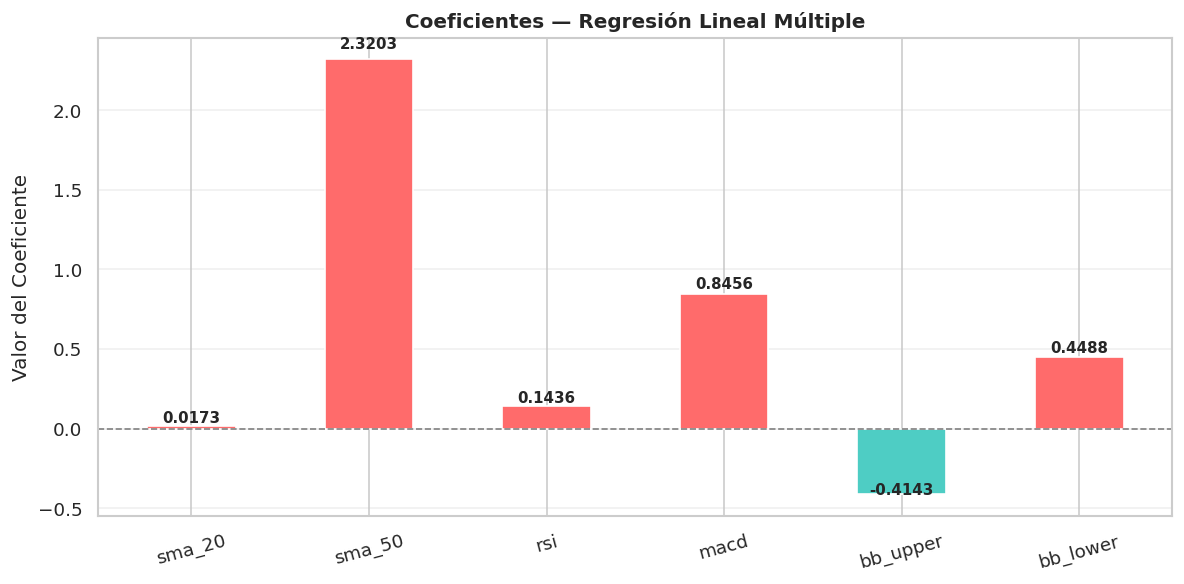

In [53]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_, color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.tick_params(axis='x', rotation=15)

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = abs(coef) * 0.02 if coef >= 0 else -abs(coef) * 0.05
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# ── CELDA 18: Métricas del modelo múltiple ───────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 50)
print('  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE')
print('=' * 50)
print(f'  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)')
print(f'  MSE  (error cuadrático med)  : {mse_m:.4f}')
print(f'  RMSE (raíz del MSE)          : {rmse_m:.4f} USD')
print(f'  MAE  (error absoluto medio)  : {mae_m:.4f} USD')
print('=' * 50)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.7316  (73.16%)
  MSE  (error cuadrático med)  : 14.3014
  RMSE (raíz del MSE)          : 3.7817 USD
  MAE  (error absoluto medio)  : 3.0837 USD


In [55]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df_model[FEATURES])
modelo_ols_multi = sm.OLS(df_model['close'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  close   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     49.11
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           6.63e-17
Time:                        00:27:08   Log-Likelihood:                -129.80
No. Observations:                  50   AIC:                             271.6
Df Residuals:                      44   BIC:                             283.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -230.2585    113.547     -2.028      0.0

### 🔬 Supuesto 3: Multicolinealidad (VIF)
`VIF(xⱼ) = 1 / (1 − R²ⱼ)` — si VIF ≥ 10 hay multicolinealidad severa.

In [57]:
# ─────────────────────────────────────────────
# INDICADORES TÉCNICOS
# ─────────────────────────────────────────────

# SMA
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26

# Bollinger (solo usamos upper para evitar colinealidad fuerte)
df['bb_middle'] = df['close'].rolling(20).mean()
rolling_std = df['close'].rolling(20).std()
df['bb_upper'] = df['bb_middle'] + 2 * rolling_std

# ─────────────────────────────────────────────
# FEATURES (SIN DEPENDENCIAS DIRECTAS)
# ─────────────────────────────────────────────

FEATURES = ['sma_50', 'rsi', 'macd', 'bb_upper']

# Crear dataset limpio
df_model = df[['close'] + FEATURES].dropna()

X = df_model[FEATURES]
y = df_model['close']

# ─────────────────────────────────────────────
# TRAIN TEST SPLIT
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ─────────────────────────────────────────────
# ENTRENAMIENTO
# ─────────────────────────────────────────────

modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)

y_pred = modelo_multi.predict(X_test)

# ─────────────────────────────────────────────
# RESULTADOS
# ─────────────────────────────────────────────

print("\n📊 MODELO MÚLTIPLE")
print(f'Intercepto β₀: {modelo_multi.intercept_:.4f}')

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>10}: {coef:.6f}')

print("\n📈 MÉTRICAS")
print(f'R²   : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

# ─────────────────────────────────────────────
# VIF (MULTICOLINEALIDAD)
# ─────────────────────────────────────────────

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n🔎 VIF — Multicolinealidad")
print(vif_data)


📊 MODELO MÚLTIPLE
Intercepto β₀: -144.7361
Coeficiente     sma_50: 1.857259
Coeficiente        rsi: 0.048557
Coeficiente       macd: 1.639895
Coeficiente   bb_upper: -0.311949

📈 MÉTRICAS
R²   : 0.7846
RMSE : 3.3876

🔎 VIF — Multicolinealidad
   Variable           VIF
0     const  41081.809659
1    sma_50     10.181489
2       rsi      6.096116
3      macd      5.453627
4  bb_upper      8.655919


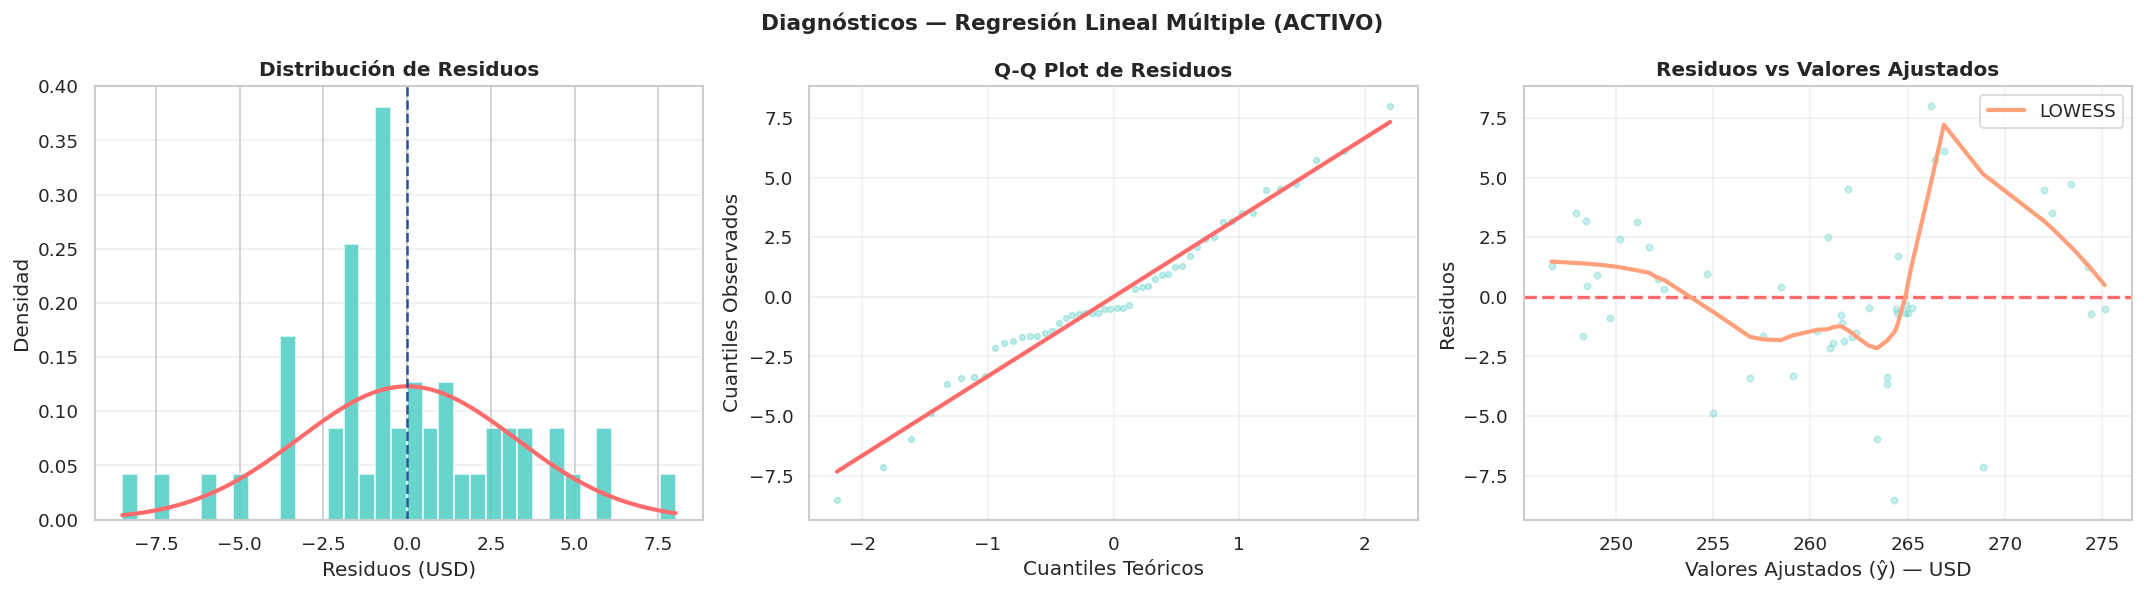


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.601062 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.162492 → ✅ Homocedasticidad OK


In [58]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Diagnósticos — Regresión Lineal Múltiple ({SYMBOL})',
             fontsize=13, fontweight='bold')

# Histograma de residuos
axes[0].hist(residuos_m, bins=35, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (USD)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ) — USD')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f'\n🔬 Test Shapiro-Wilk (Normalidad):')
print(f'   p-value: {p_sw_m:.6f} → '
      f'{"✅ No se rechaza normalidad" if p_sw_m > 0.05 else "⚠️  Se rechaza normalidad"}')

print(f'\n🔬 Test Breusch-Pagan (Homocedasticidad):')
print(f'   p-value: {lm_p_m:.6f} → '
      f'{"✅ Homocedasticidad OK" if lm_p_m > 0.05 else "⚠️  Heterocedasticidad detectada"}')

---
## 📋 Fase 6 — Comparación de Modelos

In [59]:
# ── CELDA 22: Tabla comparativa ──────────────────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['sma_20',
                  'sma_20 + sma_50 + rsi + macd + bb_upper + bb_lower'],
    'R²'       : [round(r2,   4), round(r2_m,   4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj,  4)],
    'RMSE(USD)': [round(rmse,  4), round(rmse_m,  4)],
    'MAE(USD)' : [round(mae,   4), round(mae_m,   4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic,  2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic,  2)],
})

print('=' * 90)
print('                    COMPARACIÓN DE MODELOS')
print('=' * 90)
print(comparacion.to_string(index=False))
print('=' * 90)
print('\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia')

                    COMPARACIÓN DE MODELOS
            Modelo                                          Variables      R²  R² Aj.  RMSE(USD)  MAE(USD)    AIC    BIC
  Regresión Simple                                             sma_20 -0.1216  0.1887     7.7302    6.6991 554.74 559.51
Regresión Múltiple sma_20 + sma_50 + rsi + macd + bb_upper + bb_lower  0.7316  0.8308     3.7817    3.0837 271.60 283.07

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


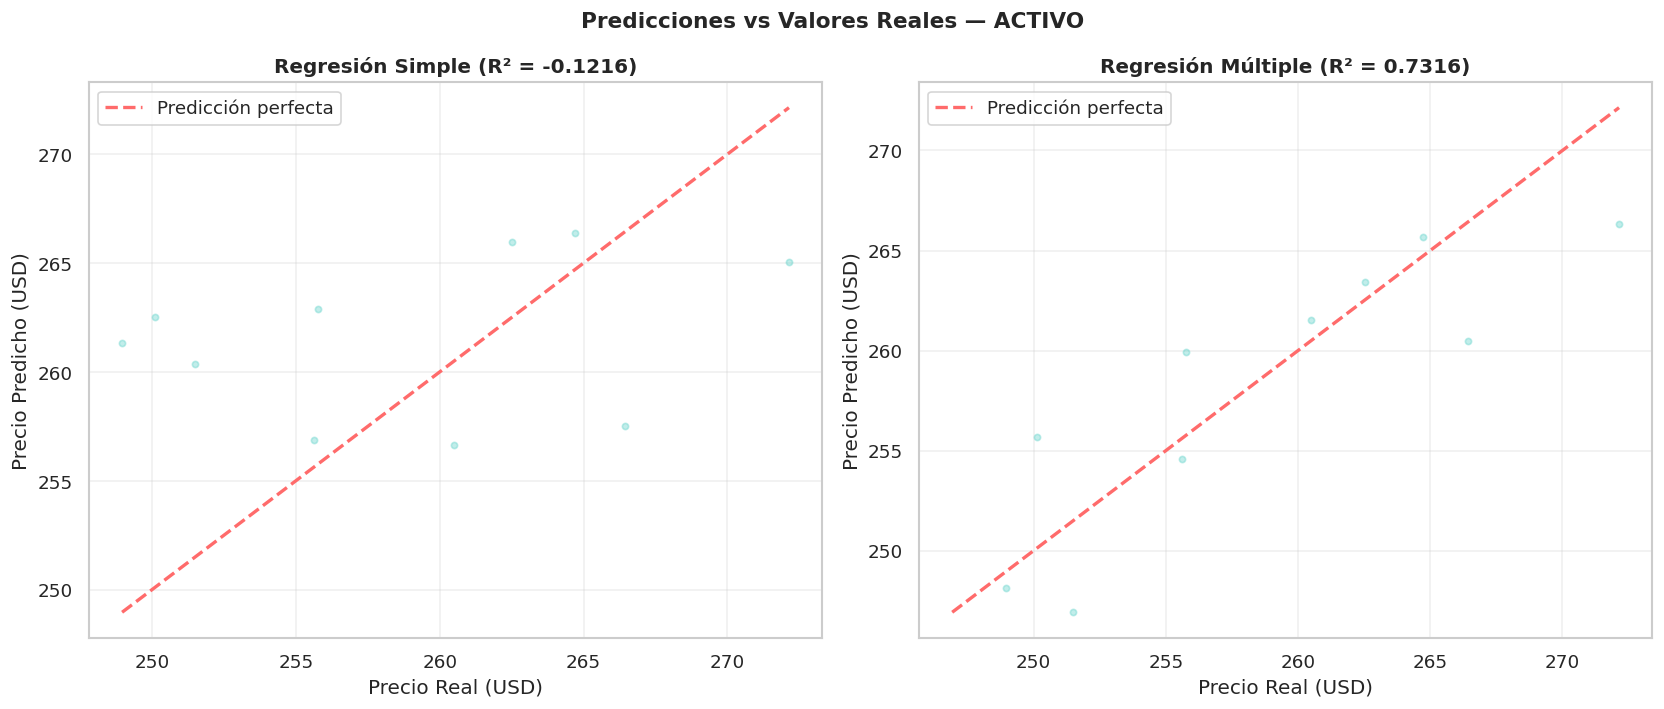

In [60]:
# ── CELDA 23: Predicciones vs Valores Reales ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Predicciones vs Valores Reales — {SYMBOL}',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.35, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--', label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Precio Real (USD)')
    ax.set_ylabel('Precio Predicho (USD)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎓 Conclusiones

1. **Correlación dominante:** La SMA-20 y SMA-50 tienen correlación muy alta con `close` porque son derivadas del propio precio, lo que produce R² muy elevados (cercanos a 1.0).

2. **Multicolinealidad esperada:** Variables como `sma_20`, `sma_50`, `bb_upper` y `bb_lower` están altamente correlacionadas entre sí. El VIF puede ser alto, lo que sugiere considerar modelos regularizados (Ridge/Lasso) en análisis avanzados.

3. **Modelo múltiple vs simple:** La mejora en RMSE al agregar indicadores técnicos es marginal si la SMA ya captura casi toda la varianza del precio.

4. **Limitación importante:** Con datos de series temporales, el split aleatorio (train_test_split) ignora la dependencia temporal. En producción se debe usar **TimeSeriesSplit** de scikit-learn.

5. **Homocedasticidad:** Los residuos del modelo financiero pueden mostrar heterocedasticidad (volatilidad variable en el tiempo), especialmente en períodos de alta volatilidad del mercado.